# Métricas de classificação

## 1. Baixando a base de dados

Usaremos o conjunto de dados dos dígitos escritos à mão. O conjunto é composto por 1797 imagens com 8x8 pixels cada.

**OBS**: O conjunto já está dividido e normalizado.

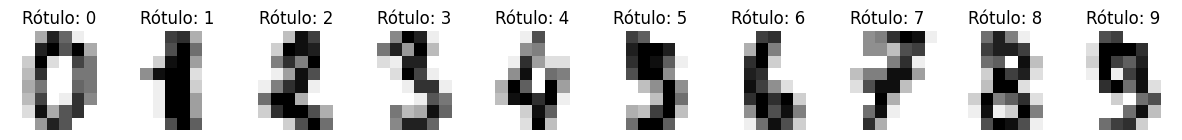

In [ ]:
# Import all necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

# Reset PN-sequence generator.
seed = 42
np.random.seed(seed)

# Loading handwritten digits dataset.
X, y = load_digits(return_X_y=True)

# Pick training and test data sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

# Scale data to have zero mean and unit variance.
scaler = MinMaxScaler((-1,1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Plot some of the images.
_, axes = plt.subplots(nrows=1, ncols=10, figsize=(15, 2))
for ax, image, label in zip(axes, X, y):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Rótulo: {label}")

## 2. Treinamento do regressor softmax

**OBS**.: Para que o modelo convirja, o número de iterações deve ser aumentado para no mínimo `max_iter=500`.


In [ ]:
# Apply softmax regressor
clf = LogisticRegression(max_iter=500, random_state=seed)

# fit data
clf.fit(X_train, y_train)

LogisticRegression(max_iter=500, random_state=42)

## 3. Cálculo das acurácias

In [ ]:
y_pred_train = clf.predict(X_train)

acc_train = accuracy_score(y_train, y_pred_train)

y_pred_test = clf.predict(X_test)

acc_test = accuracy_score(y_test, y_pred_test)

print('Train accuracy of softmax model is: %1.3f' % (acc_train*100))
print('Test accuracy of softmax model is: %1.3f' % (acc_test*100))

Train accuracy of softmax model is: 99.682
Test accuracy of softmax model is: 97.222


Como os dois resultados são altos e a diferença entre eles não é muito grande, é provavel que não esteja ocorrendo sobreajuste.

Como nos certificar?

+ Usar validação cruzada (k-fold) e observar a variância do erro/métricas.
+ Realizar a otimização dos hiperparâmetros do modelo: tipo de penalidade, fator de penalização, tipo de otimizador.


## 4. Reporte de classificação

Para analisar o desempenho do classificador, vamos usar as funções `classification_report` e `confusion_matrix` do módulo `metrics` da biblioteca Scikit-Learn.

In [ ]:
# Imprime o reporte de classificação.
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.94      0.96        50
           2       0.92      1.00      0.96        47
           3       1.00      0.94      0.97        54
           4       1.00      0.98      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.91      0.98      0.94        43
           9       0.97      0.97      0.97        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



#### Observações:

+ `macro avg` dá média aritmética **simples** das métricas para cada classe.
    + Ela atribui o mesmo peso para cada classe, independentemente do número de amostras em cada uma delas.


+ `weighted avg` dá média aritmética **ponderada** das métricas para cada classe.
    + Ela atribui pesos diferentes para cada classe, levando em consideração o número de amostras em cada uma delas.
    + Assim, classes com mais amostras tem uma contribuição maior no cálculo da métrica.

## 5. Matriz de confusão

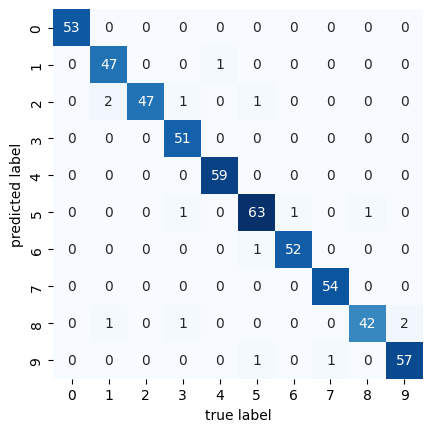

In [ ]:
# Plot the confusion matrix.
mat = confusion_matrix(y_test, y_pred_test)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, xticklabels=range(10), yticklabels=range(10), cmap="Blues")
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()